In [4]:
import os
from dotenv import load_dotenv
import time

In [5]:
load_dotenv()  # Load environment variables from .env file  (Check the variable is accessible)

True

In [6]:
# create an llm call
from langchain_google_genai import ChatGoogleGenerativeAI


In [7]:
import os
from dotenv import load_dotenv
from google import genai

load_dotenv()
client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

for m in client.models.list():
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.6-flash
models/gemini-3.7-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.6-preview
models/gemini-robotics-er-2-preview
models/gemini-2.5-computer-use-p

In [5]:
os.getenv("GOOGLE_API_KEY")
os.getenv("GROQ_API_KEY") # Check the variable is accessible

'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'

In [6]:
llm = ChatGoogleGenerativeAI(model="gemini-flash-latest")
llm.invoke("Hello,what is the capital of India?")

AIMessage(content=[{'type': 'text', 'text': 'Hello! The capital of India is **New Delhi**.', 'extras': {'signature': 'EpoDCpcDARFNMg/6sa0tADgwwTSWykYUgh/P5ojDKvdRMT6reQ+mqvOUMsqk7KV4BRWU5NAHmQs1GTgIDg+kz4Pu3VEhVQkGZvPBFR/0/XU6cr9Q9pyd/PZH1ZBHvqQRgC1854Knt3mcxjZrNVequKK20ZqB6R2b8YkTZQO7nIbyyRwjrHKDbPYVTk8XMJV+hj/Z4Q360Y81OXlo0chOBxW/gYzpkYf0b0S2mObge32LgebnfV6LVwpfSaJzDJgtUOkaj/ScaUkMZOhFz46a7/3uJid/gSHgItyc/8RKuc7WqA9aflnfVsOyalLKmTb3F41nc0vuVgzPALPwp+RcNMMsop6IZ+19dkYR3MlSsIcZBZb8JH+nW3DyVlN5jUNh8D+P9y08aGGb8YGa9Men4EEVMmdMEeuNHAK4AjjdIcLcrkJcCidUsdOH6SqFuK073Ybv+XAtelgYo5sutxfTPwFvzqqNDQLOtXjn6z/wmCES2tEjOAooz4tZl3kjk3nBtlLDIQWgSJFJ+8lfXNzNFMry1V3Fqmte4Wx+b9s='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.7-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a01a26-ab57-7791-913b-e7f804aa37f8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 85, 'total_tokens': 95,

## Import chatGroq

In [145]:
from langchain_groq import ChatGroq
llm_groq = ChatGroq(model = "openai/gpt-oss-20b",temperature=0, max_tokens=1600)

In [8]:
llm_groq.invoke("Hello?")

AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hello?" It\'s a greeting. We should respond politely. Probably ask how can I help.'}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 73, 'total_tokens': 116, 'completion_time': 0.045869444, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.0416667, 'prompt_tokens_details': None, 'queue_time': 0.205577874, 'total_time': 0.087536144}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_38cbe36ff0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a01a26-b67a-76e0-a93f-f84c1cebe474-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 43, 'total_tokens': 116, 'output_token_details': {'reasoning': 23}})

## Create the First ReAct Agent

In [9]:
from langchain.agents import create_agent
my_tools = []
my_agent = create_agent(model = llm_groq, tools = my_tools)

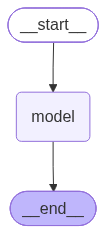

In [10]:
my_agent

In [11]:
my_agent.invoke({"messages":[("user","Hi there, How are you doing ?")]})

{'messages': [HumanMessage(content='Hi there, How are you doing ?', additional_kwargs={}, response_metadata={}, id='2ec8b60b-a09f-4d9c-ac1e-61c2fc1298d8'),
  AIMessage(content="Hello! I'm doing great—thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'The user says "Hi there, How are you doing ?" It\'s a greeting. We should respond politely. Probably "I\'m fine, thanks. How can I help you?"'}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 79, 'total_tokens': 140, 'completion_time': 0.080633643, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.003851194, 'prompt_tokens_details': None, 'queue_time': 0.139233428, 'total_time': 0.084484837}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_99996fee8e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a01a26-cb8c-7873-a0c8-24a25ae15352-0', tool_calls=[], invalid_tool_calls=[],

# Create first tool for the ReAct Agent

In [19]:
from langchain.tools import tool

In [13]:
@tool("Case_converter",description = "Covert the input text from lowercase to uppercase")
def dummy_tool (input:str)->str:
    """Convert the input text to uppercase (Only for testing purposes)
    Argument: The Input txt {str} to be converted to Uppercase
    """
    return f"Results for:{input.upper()}"

In [14]:
tools = [dummy_tool]
res = create_agent(model= llm_groq, tools = tools)

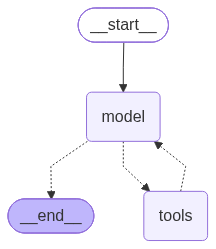

In [15]:
res

In [16]:
agent_with_tool = res.invoke({"messages":[("user", "Use the Case_converter tool on the following text message: 'Hello, How are you doing?'")]
})

In [17]:
agent_with_tool

{'messages': [HumanMessage(content="Use the Case_converter tool on the following text message: 'Hello, How are you doing?'", additional_kwargs={}, response_metadata={}, id='4e2f9bb2-a624-4a1c-93d1-8f2fefd26c54'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to use the Case_converter tool. The user says: "Use the Case_converter tool on the following text message: \'Hello, How are you doing?\'" So we need to call the function with input: \'Hello, How are you doing?\'. Then output the result. The function returns any. We need to output the result. Probably the tool will convert to uppercase. So we call the function.', 'tool_calls': [{'id': 'fc_19273a59-194c-45a4-a794-3ef9bdcc9c1d', 'function': {'arguments': '{"input":"Hello, How are you doing?"}', 'name': 'Case_converter'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 142, 'total_tokens': 257, 'completion_time': 0.142798837, 'completion_tokens_details': {'

## Create a weather update integrated ReAct Agent  

In [20]:
import requests 

In [21]:
@tool('get_weather', description = "Get the current weather of the given city using the OpenMeteo API")
def get_weather(city:str)->dict:
    """Get the current weather of the given city using OpenMeteo API"""
    try:
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en&format=json"
        geo_data = requests.get(geo_url).json()

        if not geo_data.get("results"):
            return {"Error getting in the geocoding API', {city} 'not found"}
        Location = geo_data["results"][0]
        lat = Location["latitude"]
        lon = Location["longitude"]
        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,weather_code"
        date = requests.get(weather_url).json()
        temp = date["current"]["temperature_2m"]
        return {"city": city,"temp": temp, "unit": "C"}
    except Exception as e:
        return{"Error": f"Error getting in the geocoding API, '{city}':{e}"}
    

In [22]:
print(get_weather.invoke("Berlin"))

{'city': 'Berlin', 'temp': 21.7, 'unit': 'C'}


In [23]:
tools_with_weather = [dummy_tool, get_weather]
weather_agent = create_agent(model= llm_groq, tools=tools_with_weather)
weather_agent = weather_agent.invoke({"messages":(["user","Use the get_weather tool and get the current weather of city Berlin"])})

NameError: name 'dummy_tool' is not defined

In [ ]:
weather_agent

NameError: name 'weather_agent' is not defined

In [24]:
tools = [get_weather, dummy_tool]
weather_dummy = create_agent(model =llm_groq, tools = tools)

NameError: name 'dummy_tool' is not defined

In [25]:
response2 = weather_dummy.invoke({"messages":[("user","I want o know the current weather of Ambalavayal, Kerala, India and also convert the text to uppercase ")]})

NameError: name 'weather_dummy' is not defined

## Notes tool Implimentation (Notion)

In [26]:
def safe_agent_call(agent, message, delay=10):
    time.sleep(delay)
    return agent.invoke({"messages": [("user", message)]})

In [27]:
# Get notes
@tool
def get_notes()-> list:
    """Get all pending notes from the notion database"""
    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_NOTES_DB_ID")
    data_source_id = os.getenv("NOTION_NOTES_DATA_SOURCE_ID")
    url = f"https://api.notion.com/v1/data_sources/{data_source_id}/query"
    if not api_key or not db_id or not data_source_id:
        return {"Error": "MISSING ENVIRONMENT VARIABLES OF NOTION API KEY; DB ID; DATA SOURCE ID"}
    headers = {
    "content-type": "application/json",
    "authorization": f"Bearer {api_key}",
    "Notion-Version": "2026-03-11"
    }
    payload = {  # Apply the filter in which the status is pending
        "filter": {
        "property": "Status",
        "select": {"equals":"Pending"}
        }
    }
    # Making the api request
    try:
        response = requests.post(url,headers = headers, json = payload)
        response.raise_for_status()
        data = response.json()
        # Get all the necessery data inside variables and append to the notes.
        notes = []
        for page in data.get('results',[]):
            page_id = page.get('id', "")
            props = page.get('properties',{})
            title_list = props.get('Note',{}).get('title',{})
            Note_content = title_list[0]. get('text', {}).get('content', "") if title_list else "untitled_note"
            notes.append({"content": Note_content, "id": page_id})
        return notes if notes else ["No pending notes found."]
    except requests.exceptions.RequestException as e:
        return {"Error": f"Faild to fetch the Notes: {e}"}

In [28]:
# Add note
@tool
def add_notes(note_title, note_content, status)-> str:
    """Get all pending notes from the notion database"""
    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_NOTES_DB_ID")
    data_source_id = os.getenv("NOTION_NOTES_DATA_SOURCE_ID")
    url = f"https://api.notion.com/v1/pages"
    if not api_key or not db_id or not data_source_id:
        return {"Error": "MISSING ENVIRONMENT VARIABLES OF NOTION API KEY; DB ID; DATA SOURCE ID"}
    headers ={
    "content-type": "application/json",
    "authorization": f"Bearer {api_key}",
    "Notion-Version": "2026-03-11"
    }

    payload = {
    "parent": {"type": "data_source_id", "data_source_id": data_source_id},
    "properties": {
        "Note": {"title": [{"text": {"content": note_title}}]},
        "note_content": {"rich_text": [{"text": {"content": note_content}}]},
        "Status": {"select": {"name": status}}
    }
}

    try:
        response = requests.post(url,headers = headers, json = payload)
        response.raise_for_status()
        data = response.json()
        if not api_key or not db_id or not data_source_id:
                return {"Error": "MISSING ENVIRONMENT VARIABLES OF NOTION API KEY; DB ID; DATA SOURCE ID"}
        data = response.json()
        # We have get_notes and lets create the add_notes 
        return f"Note added successfully with ID: {data['id']},status: {status}"
    except requests.exceptions.RequestException as e:
        return f"Error on adding the Note: {str(e)}"

In [29]:
import os
api_key = os.getenv("NOTION_API_KEY")
data_source_id = os.getenv("NOTION_NOTES_DATA_SOURCE_ID")

headers = {
    "authorization": f"Bearer {api_key}",
    "Notion-Version": "2026-03-11"
}

response = requests.get(f"https://api.notion.com/v1/data_sources/{data_source_id}", headers=headers)
print(response.json())

{'object': 'data_source', 'id': '0e653ebc-c588-445d-b362-535419cc2a75', 'cover': None, 'icon': None, 'created_time': '2026-08-08T09:05:00.000Z', 'created_by': {'object': 'user', 'id': '3b68fa46-5e60-813b-9836-0027dae14176'}, 'last_edited_by': {'object': 'user', 'id': '136d872b-594c-81de-9ad4-0002e9887586'}, 'last_edited_time': '2026-08-19T16:57:00.000Z', 'title': [{'type': 'text', 'text': {'content': 'Smart Task Planner Notes', 'link': None}, 'annotations': {'bold': False, 'italic': False, 'strikethrough': False, 'underline': False, 'code': False, 'color': 'default'}, 'plain_text': 'Smart Task Planner Notes', 'href': None}], 'description': [], 'is_inline': False, 'properties': {'Status': {'id': 'Vgrh', 'name': 'Status', 'description': None, 'type': 'select', 'select': {'options': [{'id': 'Ybps', 'name': 'Inprogress', 'color': 'default', 'description': None}, {'id': '1b655c16-2381-406a-a0cc-e60f9aa68d7e', 'name': 'Pending', 'color': 'yellow', 'description': None}, {'id': '8b77b367-dfbe-

In [30]:
# Create an agent which use both get and add note tools 
note_tools = [get_notes, add_notes]
notion_agent = create_agent(model = llm_groq, tools= note_tools)

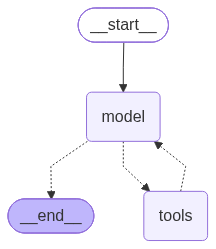

In [31]:
notion_agent

In [32]:
#response2 = safe_agent_call(notion_agent, "I want to know the current notes I have in my notion")

In [33]:
#response3 = safe_agent_call(notion_agent, "Tell me the current note I have. If I have only one note, add a new note titled LangChain_series")

In [34]:
#response4 = safe_agent_call(notion_agent, "Change the status of note Agentic_ai from Pending to Inprogress")

In [35]:
# find the page
@tool
def find_tool(note_name)->str:
    """Search for a note by its exact title and return its page ID."""
    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_NOTES_DB_ID")
    data_source_id = os.getenv("NOTION_NOTES_DATA_SOURCE_ID")
    url = f"https://api.notion.com/v1/data_sources/{data_source_id}/query"
    if not api_key or not db_id or not data_source_id:
        return {"Error": "MISSING ENVIRONMENT VARIABLES OF NOTION API KEY; DB ID; DATA SOURCE ID"}
    headers ={
    "content-type": "application/json",
    "authorization": f"Bearer {api_key}",
    "Notion-Version": "2026-03-11"
    }
    payload = {  # Apply the filter in which get the note name which is searching
        "filter": {
        "property": "Note",
        "title": {"equals": note_name}
        }
    }
    try:
        response = requests.post(url,headers = headers, json = payload, timeout=10)
        response.raise_for_status()
        data = response.json()
        results = data.get("results",[])
        if not results:
            return "Error: Unable to find the page"
        page_id = results[0].get("id","") # getting the first match from the query
        
        # We have get_notes and lets create the add_notes 
        return f"Found note with page ID: {page_id}"
    except requests.exceptions.RequestException as e:
        return f"Error on finding the Note: {str(e)}"

In [36]:
'''note_tools = [get_notes, add_notes, find_tool]
notion_agent = create_agent(model = llm_groq, tools= note_tools)
'''

'note_tools = [get_notes, add_notes, find_tool]\nnotion_agent = create_agent(model = llm_groq, tools= note_tools)\n'

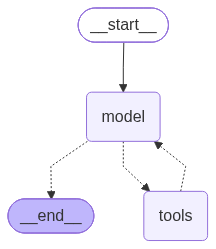

In [37]:
notion_agent

In [38]:
response5 = find_tool.invoke({"note_name": "agentic_ai"})

In [39]:
response5

'Error: Unable to find the page'

In [40]:
# trash tool
@tool
def trash_tool(note_name)->str:
    """Search for a note by its exact title and move it to trash if found."""
    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_NOTES_DB_ID")
    data_source_id = os.getenv("NOTION_NOTES_DATA_SOURCE_ID")
    url = f"https://api.notion.com/v1/data_sources/{data_source_id}/query"   # search URL, top of func  # for searching — near the top, like find_tool
    if not api_key or not db_id or not data_source_id:
        return {"Error": "MISSING ENVIRONMENT VARIABLES OF NOTION API KEY; DB ID; DATA SOURCE ID"}
    headers ={
    "content-type": "application/json",
    "authorization": f"Bearer {api_key}",
    "Notion-Version": "2026-03-11"
    }
    payload = {  # Apply the filter in which get the note name which is searching
        "filter": {
        "property": "Note",
        "title": {"equals": note_name}
        }
    }
    try:
        response = requests.post(url,headers = headers, json = payload, timeout=10)
        response.raise_for_status()
        data = response.json()
        results = data.get("results",[])
        if not results:
            return "Error: Unable to find the page"
        page_id = results[0].get("id","") # getting the first match from the query
        trash_url = f"https://api.notion.com/v1/pages/{page_id}"   # trash URL, AFTER page_id exist
        trash_payload = {"in_trash": True}
        trash_response = requests.patch(trash_url,headers = headers, json = trash_payload, timeout=10)
        trash_response.raise_for_status()
        return f"Note '{note_name}' has been moved to trash."
    except requests.exceptions.RequestException as e:
        return f"Error on trashing the Note: {str(e)}"

In [41]:
response5 = trash_tool.invoke({"note_name": "agentic_ai"})

In [42]:
response5

'Error: Unable to find the page'

## Calander_tool implimentation (Notion)

In [43]:
import os
api_key = os.getenv("NOTION_API_KEY")
data_source_id = os.getenv("NOTION_CALENDAR_DATA_SOURCE_ID")
headers = {
    "authorization": f"Bearer {api_key}",
    "Notion-Version": "2026-03-11"
}
response = requests.get(f"https://api.notion.com/v1/data_sources/{data_source_id}", headers=headers)
print(response.json().get("properties"))

{'Time': {'id': 'QOYW', 'name': 'Time', 'description': None, 'type': 'rich_text', 'rich_text': {}}, 'Date': {'id': 'RU~q', 'name': 'Date', 'description': None, 'type': 'date', 'date': {}}, 'Status': {'id': 'pxoG', 'name': 'Status', 'description': None, 'type': 'select', 'select': {'options': [{'id': '70f1b9fa-c9f1-4148-a396-8c6262665347', 'name': 'Upcoming', 'color': 'gray', 'description': None}, {'id': '4769de3c-aa09-42c3-b606-d3a19f728d96', 'name': 'In Progress', 'color': 'blue', 'description': None}, {'id': '1cfd64cc-af76-4f60-b5e7-f1ea0e7c3924', 'name': 'Done', 'color': 'green', 'description': None}, {'id': '5756a5d4-531e-4e0c-9f98-5f35fd0391bc', 'name': 'Cancelled', 'color': 'red', 'description': None}, {'id': 'b4d5cb70-664a-4e3f-b642-9185e4eaf448', 'name': 'confirmed', 'color': 'default', 'description': None}, {'id': 'a82144ef-bd00-4dc4-a513-e4013b3768e5', 'name': 'Scheduled', 'color': 'purple', 'description': None}]}}, 'Event': {'id': 'title', 'name': 'Event', 'description': Non

In [44]:
# Get event
@tool
def get_event(date)->dict:
    """This tool will get the calander events for a spacific date (YYYY-MM-DD) from Notion"""
    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_CALENDAR_DB_ID")
    data_source_id = os.getenv("NOTION_CALENDAR_DATA_SOURCE_ID")
    url = f"https://api.notion.com/v1/data_sources/{data_source_id}/query"   # search URL, top of func  # for searching — near the top, like find_tool
    if not api_key or not db_id or not data_source_id:
        return {"Error": "MISSING ENVIRONMENT VARIABLES OF NOTION API KEY; DB ID; DATA SOURCE ID"}
    headers ={
    "content-type": "application/json",
    "authorization": f"Bearer {api_key}",
    "Notion-Version": "2026-03-11"
    }
    payload = {  
        "filter": {
        "property": "Date",
        "date": {"equals": date}
        }
    }

    try:
        response = requests.post(url,headers = headers, json = payload, timeout=10)
        response.raise_for_status()
        data = response.json()
    
        events = []
        for page in data.get("results",[]):
            props = page.get("properties", {})

            # Extracting the event title
            event_title_list = props.get("Event", {}).get("title",[])
            event_name = event_title_list[0].get("text",{}).get('content', "") if event_title_list else "Untitled event"

            # Extracting the Event time
            time_list = props.get("Time", {}). get("rich_text", [])
            event_time = time_list[0].get("text", {}).get("content", "") if time_list else "All_day"
            events.append({"Event": event_name, 'event_time':event_time})
        return {"events": events, "date": date}
    except requests.exceptions.RequestException as e:
        print(response.text)
        return f"Error fetching calendar event: {str(e)}"


In [45]:
calander_event = get_event.invoke({"date":"2026-08-17"})

In [46]:
calander_event

{'events': [], 'date': '2026-08-17'}

In [137]:
# Create calander_event
@tool
def new_event(event_name, date, time, status)->dict:
    """This tool will create a new event for the input date"""
    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_CALENDAR_DB_ID")
    data_source_id = os.getenv("NOTION_CALENDAR_DATA_SOURCE_ID")
    url = f"https://api.notion.com/v1/pages"   # create event
    if not api_key or not db_id or not data_source_id:
        return {"Error": "MISSING ENVIRONMENT VARIABLES OF NOTION API KEY; DB ID; DATA SOURCE ID"}
    headers ={
    "content-type": "application/json",
    "authorization": f"Bearer {api_key}",
    "Notion-Version": "2026-03-11"
    } 
    start_datetime = f"{date}T{time}:00+02:00" if time else date 
    payload = {
        "parent": {"type": "data_source_id", "data_source_id":data_source_id}, 
        "properties":{
               "Event": {"title": [{'text':{'content': event_name}}]},
               "Date": {"date":{"start": start_datetime}},
               "Time": {"rich_text": [{"text": {"content": time}}]},
               "Status": {"select": {"name": status}}
        }
    }
    try:
        response = requests.post(url,headers = headers, json = payload, timeout=10)
        response.raise_for_status()
        if not api_key or not db_id or not data_source_id:
                return {"Error": "MISSING ENVIRONMENT VARIABLES OF NOTION API KEY; DB ID; DATA SOURCE ID"}
        data = response.json()
        # We have get_notes and lets create the add_notes 
        return f"Event added successfully with name: {event_name},Start_Time: {time}, Date: {date}"
    except requests.exceptions.RequestException as e:
        print(response.text) 
        return f"Error creating event: {str(e)}"

In [111]:
result = new_event.invoke({
    "event_name": "Timezone test",
    "date": "2026-08-22",
    "time": "10:00",
    "status": "Upcoming"
})
print(result)

Event added successfully with name: Timezone test,Start_Time: 10:00, Date: 2026-08-22


In [49]:
create_event

'Event added successfully with name: System thinking session,Start_Time: 10:00, Date: 2026-08-18'

In [50]:
# Trash event
@tool
def trash_event(event_name)-> str:
    "this tool will identify and trash the created event"
    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_CALENDAR_DB_ID")
    data_source_id = os.getenv("NOTION_CALENDAR_DATA_SOURCE_ID")
    url = f"https://api.notion.com/v1/data_sources/{data_source_id}/query"   # query endpoint
    if not api_key or not db_id or not data_source_id:
        return {"Error": "MISSING ENVIRONMENT VARIABLES OF NOTION API KEY; DB ID; DATA SOURCE ID"}
    headers ={
    "content-type": "application/json",
    "authorization": f"Bearer {api_key}",
    "Notion-Version": "2026-03-11"
    } 
    payload = {
        "filter" : {
            "property":"Event",
            "title": {"equals" : event_name}
        }
    }
    try:
        response = requests.post(url,headers = headers, json = payload, timeout=10)
        response.raise_for_status()
        data = response.json()
        results = data.get("results",[])
        if not results:
            return "Error: Unable to find the event"
        page_id = results[0].get("id","") # getting the first match from the query
        trash_url = f"https://api.notion.com/v1/pages/{page_id}"  # trash URL, AFTER page_id exist
        trash_payload = {"in_trash": True}
        trash_response = requests.patch(trash_url,headers = headers, json = trash_payload, timeout=10)
        trash_response.raise_for_status()
        return f"Event '{event_name}' has been moved to trash."
    except requests.exceptions.RequestException as e:
        print(response.text)
        return f"Error on trashing the event: {str(e)}"

In [51]:
trash_event.invoke({"event_name": "10 hours agentic ai tutorial by krish naik"})

'Error: Unable to find the event'

In [52]:
trash_event

StructuredTool(name='trash_event', description='this tool will identify and trash the created event', args_schema=<class 'langchain_core.utils.pydantic.trash_event'>, func=<function trash_event at 0x00000213966F5850>)

## Multi_tool reAct Agent

In [139]:
Notion_tools = [get_notes, add_notes, find_tool,trash_tool, get_event, new_event, trash_event,get_weather]
notion_agent = create_agent(model = llm_groq, tools= Notion_tools)


In [140]:
query = "Create a new event in my notion for tomorrow after noon 4 clock and name it ReAct Agent project publish also delete all if it is duplicated"
response = notion_agent.invoke({"messages": [("user", query)]})


In [129]:
response

{'messages': [HumanMessage(content='Create a new event in my notion for tomorrow after noon 4 clock and name it ReAct Agent project publish also delete all if it is duplicated', additional_kwargs={}, response_metadata={}, id='18e24d73-bc8c-4e74-b7d3-3564aa8e4345'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to create a new event in Notion for tomorrow after noon 4 clock, name it "ReAct Agent project publish". Also delete all if it is duplicated. So we need to check if an event with that name exists. If yes, delete it. Then create new event. We need to use get_event to check events for tomorrow\'s date. Then find if any event with name "ReAct Agent project publish". If found, trash_event. Then new_event.\n\nWe need to get tomorrow\'s date. Today is 2026-08-20. Tomorrow is 2026-08-21. Time: after noon 4 clock. So time "16:00". Status maybe "planned" or something. We\'ll use status "planned".\n\nWe need to call get_event with date "2026-08-21". Then parse res

In [130]:
result = get_event.invoke({"date": "2026-08-20"})
print(result)

{'events': [], 'date': '2026-08-20'}


## Apply System prompt to the ReAct Agent

In [146]:
from datetime import datetime
now = datetime.now()
syst_prompt = f"""
"System prompt - Smart day planner (ReAct Agent)
1. Role & Goal
You act as a ReAct agent which helps the user to plan, prioritize and optimize the day of the user.
2. Dynamic Context
Current_Date = {now.strftime('%Y-%m-%d')}
Current_Time = {now.strftime('%H-%M')}
3. Task_Instruction
Follow the ReAct pattern:
- Reason about priorities, trade-offs, and time allocation
- Act by producing a realistic and actionable plan
Break work into focused block and avoid overload, check dependancies with each task and align it.
Ask clarifying question only if needed
4. Example
User:
"I have an assignment, German study, gym, and emails to finish today. I have a meeting at 6 PM."

Agent:
- Prioritize the assignment and meeting.
- Schedule emails and German study around them.
- Keep gym optional if time is limited.
- Include breaks.
- Give a clear time-based schedule.

5. Critical Rules

- Use the current date and time.
- Never schedule tasks in the past.
- Aim to avoid overlapping tasks; check this once when placing each new event, not repeatedly.
- Prioritize deadlines and fixed commitments.
- Follow the user's stated priorities.
- Do not invent deadlines or commitments.
- Keep the schedule realistic.
- Include breaks when needed.
- If everything cannot fit, prioritize and postpone lower-priority tasks.
- Clearly mark optional tasks.
- Ask for clarification only when necessary.
- Do not reveal internal reasoning.
- Always provide an actionable plan.
6. Tool Usage Rule
When the user's plan involves checking existing notes/events or creating new ones, 
you MUST use your available tools (get_event, new_event, add_notes, trash_tool, trash_event) to perform the real action — never just describe it as text in the plan. 
Use tool results to inform the schedule you produce.
7. Action-First Rule
Before asking any clarifying question, first complete every action you already have enough information for (checking events, creating notes, creating events, etc.). 
Only ask about the specific missing detail once all other possible actions are done. Never let one ambiguous detail block or delay actions that don't depend on it.
8. Date & Time Format Rule
Always use YYYY-MM-DD for dates (e.g. 2026-08-27). When creating an event, the "time" argument must be a single start time only (e.g. "13:00"), never a range like "13:00-14:00" — the tool itself calculates duration separately.

"""


In [147]:
agent_with_syst_prompt = create_agent(model=llm_groq, tools = Notion_tools, system_prompt= syst_prompt)

In [149]:
query = (
    "Tomorrow, check the weather in Berlin. "
    "If it's below 12 degrees, postpone my gym to 4 PM–6 PM and add that as a calendar event. "
    "Otherwise, schedule the gym at 3 PM as a calendar event. "
    "Add breakfast as a 15-minute event starting at 10 AM. "
    "In the afternoon, check Notion for tomorrow's upcoming events. "
    "If there are none, create an event called 'AI news reading' from 1 PM for 1 hour. "
    "At 7 PM, add a calendar event reminder for the movie I'm going to. "
    "Also create a note titled 'Meeting agenda for AI infrastructure' for tomorrow's meeting."
)
response = agent_with_syst_prompt.invoke({"messages": [("user", query)]})

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01kz8xx4yje6e8mmsd6pv67spw` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Used 6149, Requested 2929. Please try again in 8.085s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [144]:
response

{'messages': [HumanMessage(content="Tomorrow, check the weather in Berlin. If it's below 12 degrees, postpone my gym to 4 PM–6 PM and add that as a calendar event. Otherwise, schedule the gym at 3 PM as a calendar event. Add breakfast as a 15-minute event starting at 10 AM. In the afternoon, check Notion for tomorrow's upcoming events. If there are none, create an event called 'AI news reading' from 1 PM for 1 hour. At 7 PM, add a calendar event reminder for the movie I'm going to. Also create a note titled 'Meeting agenda for AI infrastructure' for tomorrow's meeting.", additional_kwargs={}, response_metadata={}, id='887dea16-2f05-474c-b0fa-44ad51884c9d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to follow ReAct pattern. We have to use tools. Steps:\n\n1. Check weather in Berlin. Use get_weather tool. Need city "Berlin". We\'ll call get_weather.\n\n2. Based on temperature, decide gym time. But we need to know the temperature. So we must wait for tool re